In [5]:
import geopandas as gpd
from shapely.geometry import box

# Load files
coastline = gpd.read_file('../../data/coastline/lines.shp')
land = gpd.read_file('../../data/coastline/GSHHS_f_L1.shp')

# WIO bbox
bbox_geom = box(32.0, -27.0, 42.0, 5.0)  # (min_lon, min_lat, max_lon, max_lat)

# Crop
wio_coastline = coastline[coastline.intersects(bbox_geom)].copy()
wio_coastline['geometry'] = wio_coastline.geometry.intersection(bbox_geom)

wio_land = land[land.intersects(bbox_geom)].copy()
wio_land['geometry'] = wio_land.geometry.intersection(bbox_geom)

# Save
wio_coastline.to_file('../../data/coastline/coastline_lines_wio.shp')
wio_land.to_file('../../data/coastline/coastline_land_wio.shp')

print(f"Coastline: {len(coastline):,} → {len(wio_coastline):,}")
print(f"Land:      {len(land):,} → {len(wio_land):,}")

Coastline: 858,199 → 1,247
Land:      179,837 → 719


In [6]:
import geopandas as gpd
import folium

# Load cropped files
wio_coastline = gpd.read_file('../../data/coastline/coastline_lines_wio.shp')
wio_land = gpd.read_file('../../data/coastline/coastline_land_wio.shp')

# Get center point
bounds = wio_land.total_bounds  # [minx, miny, maxx, maxy]
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# Create map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
    tiles='OpenStreetMap'
)

# Add land polygons
folium.GeoJson(
    wio_land,
    name='Land',
    style_function=lambda x: {
        'fillColor': 'lightgreen',
        'color': 'darkgreen',
        'weight': 1,
        'fillOpacity': 0.4
    }
).add_to(m)

# Add coastline
folium.GeoJson(
    wio_coastline,
    name='Coastline',
    style_function=lambda x: {
        'color': 'blue',
        'weight': 2
    }
).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Save
m.save('wio_coastline_interactive.html')
print("✓ Interactive map saved to: wio_coastline_interactive.html")

✓ Interactive map saved to: wio_coastline_interactive.html


Coastline bounds:
  [ 32.4807935 -27.         42.          0.0745374]
  Lon: 32.5 to 42.0
  Lat: -27.0 to 0.1

Land bounds:
  [ 32. -27.  42.   5.]
  Lon: 32.0 to 42.0
  Lat: -27.0 to 5.0

Expected WIO bbox: (32.0, -27.0, 42.0, 5.0)


NameError: name 'plt' is not defined

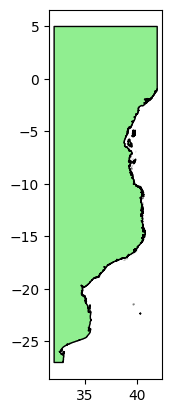

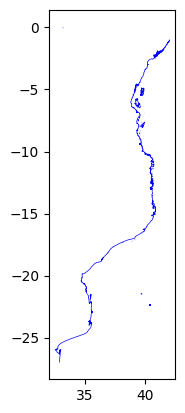

In [7]:
import geopandas as gpd

wio_coastline = gpd.read_file('../../data/coastline/coastline_lines_wio.shp')
wio_land = gpd.read_file('../../data/coastline/coastline_land_wio.shp')

print("Coastline bounds:")
print(f"  {wio_coastline.total_bounds}")
print(f"  Lon: {wio_coastline.total_bounds[0]:.1f} to {wio_coastline.total_bounds[2]:.1f}")
print(f"  Lat: {wio_coastline.total_bounds[1]:.1f} to {wio_coastline.total_bounds[3]:.1f}")

print("\nLand bounds:")
print(f"  {wio_land.total_bounds}")
print(f"  Lon: {wio_land.total_bounds[0]:.1f} to {wio_land.total_bounds[2]:.1f}")
print(f"  Lat: {wio_land.total_bounds[1]:.1f} to {wio_land.total_bounds[3]:.1f}")

print("\nExpected WIO bbox: (32.0, -27.0, 42.0, 5.0)")

# Simple plot
wio_land.plot(color='lightgreen', edgecolor='black')
wio_coastline.plot(color='blue', linewidth=0.5)
plt.title('WIO Coastline & Land')
plt.show()